# HR Attrition Analysis - Statistical Hypothesis Testing

This notebook complements the Tableau dashboard in this repository with statistical hypothesis testing in Python, using the same HR Data.xlsx dataset (1,470 employees, 16.12% attrition rate).

## Objective
Test whether overtime, monthly income, and department are statistically associated with employee attrition.

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('HR Data.xlsx')
df.shape

(1470, 39)

In [2]:
attrition_rate = (df['Attrition'] == 'Yes').mean()
print(f'Attrition rate: {attrition_rate:.2%}')

Attrition rate: 16.12%


## Hypothesis 1: Overtime and Attrition (Chi-Square Test)

H0: Attrition is independent of overtime status.
H1: Attrition is associated with overtime status.

Chi2: 87.56429365828768 p-value: 8.158423721538322e-21


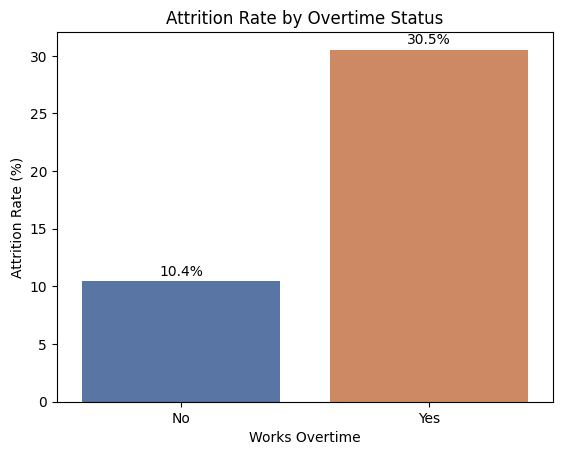

In [15]:
ct = pd.crosstab(df['Over Time'], df['Attrition'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print('Chi2:', chi2, 'p-value:', p)

rates = df.groupby('Over Time')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
sns.barplot(x=rates.index, y=rates.values, hue=rates.index, palette=['#4C72B0','#DD8452'], legend=False)
for i, v in enumerate(rates.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Works Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

### Insight
Chi-square = 87.56, p < 0.001. Employees who work overtime attrite at 30.53%, compared to 10.44% for those who don't - a statistically significant and practically large difference.

## Hypothesis 2: Monthly Income and Attrition (T-Test)

H0: Mean Monthly Income is the same for employees who left and stayed.
H1: Mean Monthly Income differs between the two groups.

t-statistic: -7.482621586644742 p-value: 4.433588628286071e-13


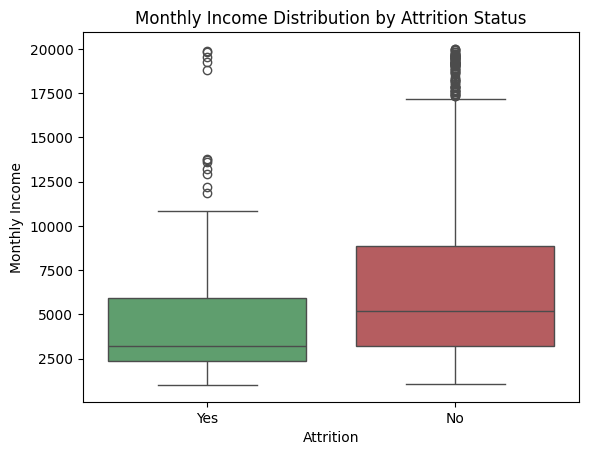

In [8]:
left = df[df['Attrition'] == 'Yes']['Monthly Income']
stayed = df[df['Attrition'] == 'No']['Monthly Income']

t_stat, p_value = stats.ttest_ind(left, stayed, equal_var=False)
print('t-statistic:', t_stat, 'p-value:', p_value)

sns.boxplot(x='Attrition', y='Monthly Income', data=df, hue='Attrition', palette=['#55A868','#C44E52'], legend=False)
plt.title("Monthly Income Distribution by Attrition Status")
plt.show()

### Insight
t = -7.48, p < 0.001. Employees who left earned $4,787 on average versus $6,833 for those who stayed - a statistically significant gap of over $2,000/month.

## Hypothesis 3: Work-Life Balance Across Departments (ANOVA)

H0: Mean Work-Life Balance score is the same across all departments.
H1: At least one department differs from the others.

F-statistic: 4.213141397138218 p-value: 0.0149792760886913


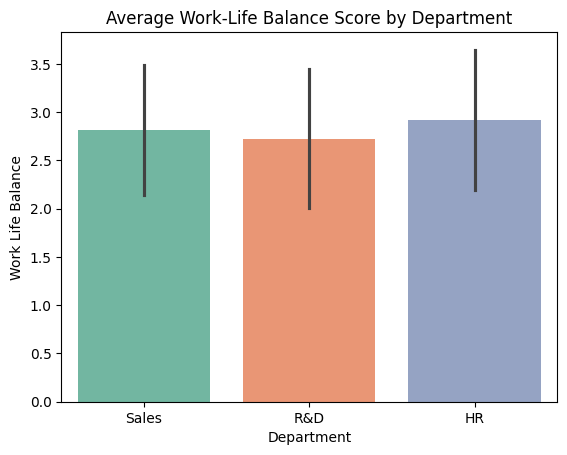

In [10]:
groups = [g['Work Life Balance'].values for name, g in df.groupby('Department')]
f_stat, p_value = stats.f_oneway(*groups)
print('F-statistic:', f_stat, 'p-value:', p_value)

sns.barplot(x='Department', y='Work Life Balance', data=df, hue='Department', palette='Set2', legend=False, errorbar='sd')
plt.title("Average Work-Life Balance Score by Department")
plt.show()

### Insight
F = 4.21, p = 0.015. R&D has the lowest average work-life balance (2.73) compared to HR (2.92) and Sales (2.82) - statistically significant, though the practical gap is small.

## Conclusion
Overtime and compensation show the strongest statistical relationships with attrition, both significant at p < 0.001. Department-level work-life balance differences are also significant (p = 0.015) but comparatively modest in size. These results suggest overtime management and compensation review as the higher-priority levers for reducing attrition.